# U-Net + FiLM Time Conditioning for Tropical Cyclone Forecasting

**Improvement over baseline U-Net:** Adds FiLM (Feature-wise Linear Modulation) layers
that condition every conv block on temporal features (storm progress, hour-of-day,
month cyclical encoding). This gives the model explicit awareness of *when* in the
storm lifecycle each frame occurs.

**Architecture:** 4-level U-Net encoder-decoder with SE attention, residual connections,
and FiLM conditioning at every level (encoder, bottleneck, decoder).

**Training:** WP basin → zero-shot SP transfer → fine-tune on SP.

## Section 0: Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
from pathlib import Path
from collections import Counter
from copy import deepcopy
from tqdm.auto import tqdm
import warnings, os, multiprocessing

warnings.filterwarnings("ignore")
multiprocessing.set_start_method("fork", force=True)
sns.set_theme(style="whitegrid", font_scale=1.1)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ── Architecture ──
N_LEVELS      = 4
BASE_CHANNELS = 32
HEAD_DIM      = 256
IN_CHANNELS   = 15
TIME_DIM      = 6
TIME_EMB_DIM  = 64

# ── Regularisation ──
DROPOUT       = 0.2
DROP_PATH     = 0.0
LABEL_SMOOTH  = 0.05

# ── Training ──
BATCH_SIZE    = 64
LR            = 5e-4
WEIGHT_DECAY  = 1.3e-3
EPOCHS        = 300
PATIENCE      = 50
DIR_WEIGHT    = 0.55

# ── Augmentation ──
USE_MIXUP      = True
USE_CUTOUT     = True
CUTOUT_SIZE    = 16
CUTOUT_N       = 2
USE_NOISE      = True
NOISE_STD      = 0.05
USE_CHAN_DROP   = True
CHAN_DROP_PROB  = 0.15

USE_ENV = True
USE_1D  = True

FT_LR       = 1e-4
FT_EPOCHS   = 80
FT_PATIENCE = 15

N_DIR_CLASSES = 8
N_INT_CLASSES = 4
DIR_LABELS  = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]
INTE_LABELS = ["Weakening", "Steady", "Slow-intens.", "Rapid-intens."]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'CPU'})")

Device: cuda (NVIDIA GeForce RTX 5090)


## Section 1: Data Loading & Dataset

In [2]:
SPLITS = {
    "wp_train":    {"reflected": False},
    "wp_val":      {"reflected": False},
    "sp_test":     {"reflected": True},
    "sp_ft_train": {"reflected": True},
    "sp_ft_val":   {"reflected": True},
}

raw = {}
for split in SPLITS:
    raw[split] = {
        "grids":  torch.load(DATA_DIR / "grids"  / f"{split}_grids.pt",  weights_only=False),
        "env":    torch.load(DATA_DIR / "env"    / f"{split}_env.pt",    weights_only=False),
        "data1d": torch.load(DATA_DIR / "data1d" / f"{split}_1d.pt",    weights_only=False),
        "labels": torch.load(DATA_DIR / "labels" / f"{split}_labels.pt", weights_only=False),
        "time":   torch.load(DATA_DIR / "time"   / f"{split}_time.pt",  weights_only=False),
    }

for s, d in raw.items():
    n = sum(v.shape[0] for v in d["grids"].values())
    print(f"  {s:15s}: {len(d['grids']):3d} storms, {n:5d} timesteps")

  wp_train       : 105 storms,  3716 timesteps
  wp_val         :  26 storms,   846 timesteps
  sp_test        :  15 storms,   427 timesteps
  sp_ft_train    :  12 storms,   402 timesteps
  sp_ft_val      :   3 storms,    93 timesteps


In [3]:
class CycloneDataset(Dataset):
    """Timestep-level samples with time features. Returns 6-tuple."""
    def __init__(self, grids, env, data1d, labels, time_feats,
                 use_reflected=False, d1d_mean=None, d1d_std=None):
        self.samples = []
        dir_key = "direction_reflected" if use_reflected else "direction"
        for storm_id in grids:
            g, e, d, t = grids[storm_id], env[storm_id], data1d[storm_id], time_feats[storm_id]
            d_lbl, i_lbl = labels[storm_id][dir_key], labels[storm_id]["intensity"]
            for idx in range(g.shape[0]):
                if d_lbl[idx].item() == -1 or i_lbl[idx].item() == -1:
                    continue
                self.samples.append((g[idx], e[idx], d[idx], t[idx],
                                     d_lbl[idx].long(), i_lbl[idx].long()))
        if d1d_mean is None:
            all_1d = torch.stack([s[2] for s in self.samples])
            self.d1d_mean = all_1d.mean(0)
            self.d1d_std  = all_1d.std(0).clamp(min=1e-6)
        else:
            self.d1d_mean, self.d1d_std = d1d_mean, d1d_std

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        grid, env, d1d, tf, dl, il = self.samples[idx]
        return grid, env, (d1d - self.d1d_mean) / self.d1d_std, tf, dl, il


datasets = {}
datasets["wp_train"] = CycloneDataset(
    raw["wp_train"]["grids"], raw["wp_train"]["env"],
    raw["wp_train"]["data1d"], raw["wp_train"]["labels"], raw["wp_train"]["time"])
d1d_mean, d1d_std = datasets["wp_train"].d1d_mean, datasets["wp_train"].d1d_std

for split, cfg in SPLITS.items():
    if split == "wp_train": continue
    datasets[split] = CycloneDataset(
        raw[split]["grids"], raw[split]["env"], raw[split]["data1d"],
        raw[split]["labels"], raw[split]["time"],
        use_reflected=cfg["reflected"], d1d_mean=d1d_mean, d1d_std=d1d_std)

loaders = {s: DataLoader(datasets[s], batch_size=BATCH_SIZE,
                         shuffle=(s=="wp_train"), num_workers=4,
                         pin_memory=True, persistent_workers=True)
           for s in SPLITS}

for s, ds in datasets.items():
    print(f"  {s:15s}: {len(ds):5d} samples")

  wp_train       :  3252 samples
  wp_val         :   730 samples
  sp_test        :   367 samples
  sp_ft_train    :   354 samples
  sp_ft_val      :    81 samples


In [4]:
# ── Class weights ──
dir_counts, int_counts = Counter(), Counter()
for *_, dl, il in datasets["wp_train"].samples:
    dir_counts[dl.item()] += 1
    int_counts[il.item()] += 1

def inv_freq(counts, n):
    total = sum(counts.values())
    return torch.tensor([total / max(counts.get(c,1),1) / n for c in range(n)])

dir_weights = inv_freq(dir_counts, N_DIR_CLASSES)
int_weights = inv_freq(int_counts, N_INT_CLASSES)
print("Dir weights:", dir_weights.numpy().round(3))
print("Int weights:", int_weights.numpy().round(3))

Dir weights: [ 1.865 14.017 22.583  6.556  0.443  0.409  0.768  0.836]
Int weights: [0.545 4.212 0.723 1.831]


## Section 2: FiLM U-Net Architecture

FiLM (Feature-wise Linear Modulation) conditions each conv block on a time embedding:
`output = gamma * features + beta` where gamma/beta are predicted from the time vector.
This is injected after every ConvBlock's second BatchNorm, before the residual add.

In [5]:
class FiLMLayer(nn.Module):
    """Feature-wise Linear Modulation. Identity-init (gamma=1, beta=0)."""
    def __init__(self, cond_dim, channels):
        super().__init__()
        self.fc = nn.Linear(cond_dim, channels * 2)
        nn.init.zeros_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)
        self.fc.bias.data[:channels] = 1.0  # gamma=1

    def forward(self, x, cond):
        gamma, beta = self.fc(cond).chunk(2, dim=1)
        return gamma.unsqueeze(-1).unsqueeze(-1) * x + beta.unsqueeze(-1).unsqueeze(-1)


class DropPath(nn.Module):
    def __init__(self, p=0.0):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training or self.p == 0.0: return x
        keep = torch.rand(x.size(0), 1, 1, 1, device=x.device) > self.p
        return x * keep / (1 - self.p)


class ConvBlock(nn.Module):
    """Double conv with residual + FiLM after second BN."""
    def __init__(self, in_ch, out_ch, cond_dim, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()
        self.drop2d = nn.Dropout2d(dropout)
        self.film = FiLMLayer(cond_dim, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.drop_path = DropPath(drop_path)

    def forward(self, x, cond):
        h = self.act(self.bn1(self.conv1(x)))
        h = self.drop2d(h)
        h = self.bn2(self.conv2(h))
        h = self.film(h, cond)
        h = self.act(h)
        return self.drop_path(h) + self.residual(x)


class SEBlock(nn.Module):
    def __init__(self, ch, r=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, max(ch//r, 4)), nn.GELU(),
            nn.Linear(max(ch//r, 4), ch), nn.Sigmoid())
    def forward(self, x): return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, cond_dim, dropout, drop_path)
        self.se = SEBlock(out_ch)
        self.pool = nn.MaxPool2d(2, ceil_mode=True)
    def forward(self, x, cond):
        skip = self.se(self.conv(x, cond))
        return skip, self.pool(skip)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, cond_dim, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch, 2, stride=2)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch, cond_dim, dropout, drop_path)
    def forward(self, x, skip, cond):
        x = self.up(x)
        dh, dw = x.size(2) - skip.size(2), x.size(3) - skip.size(3)
        if dh > 0 or dw > 0:
            x = x[:, :, dh//2:dh//2+skip.size(2), dw//2:dw//2+skip.size(3)]
        elif dh < 0 or dw < 0:
            x = F.pad(x, [0, -dw, 0, -dh])
        return self.conv(torch.cat([x, skip], 1), cond)

In [6]:
class UNetFiLM2dClassifier(nn.Module):
    """U-Net with FiLM time conditioning at every level."""
    def __init__(self, in_channels=15, base_channels=32, n_levels=4,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, time_dim=6, time_emb_dim=64,
                 use_env=True, use_1d=True,
                 dropout=0.0, head_dim=128, drop_path=0.1):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d

        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_emb_dim), nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim))

        dp = [drop_path * i / max(n_levels, 1) for i in range(n_levels + 1)]

        self.encoders = nn.ModuleList()
        ch = in_channels
        for i in range(n_levels):
            out = base_channels * (2 ** i)
            self.encoders.append(EncoderBlock(ch, out, time_emb_dim, dropout, dp[i]))
            ch = out

        bneck = base_channels * (2 ** n_levels)
        self.bottleneck = ConvBlock(ch, bneck, time_emb_dim, dropout, dp[n_levels])

        self.decoders = nn.ModuleList()
        ch = bneck
        for i in range(n_levels - 1, -1, -1):
            skip_ch = base_channels * (2 ** i)
            self.decoders.append(DecoderBlock(ch, skip_ch, skip_ch, time_emb_dim, dropout, dp[i]))
            ch = skip_ch

        self.gap = nn.AdaptiveAvgPool2d(1)
        fuse = base_channels + (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        self.head_dir = nn.Sequential(
            nn.Linear(fuse, head_dim), nn.GELU(), nn.Dropout(dropout*2),
            nn.Linear(head_dim, head_dim//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim//2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(fuse, head_dim), nn.GELU(), nn.Dropout(dropout*2),
            nn.Linear(head_dim, head_dim//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim//2, n_int_classes))

    def forward(self, grid, env=None, d1d=None, time_feat=None):
        t = self.time_mlp(time_feat)
        skips, x = [], grid
        for enc in self.encoders:
            skip, x = enc(x, t)
            skips.append(skip)
        x = self.bottleneck(x, t)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip, t)
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        f = torch.cat(parts, 1)
        return self.head_dir(f), self.head_int(f)


model = UNetFiLM2dClassifier(
    in_channels=IN_CHANNELS, base_channels=BASE_CHANNELS, n_levels=N_LEVELS,
    time_dim=TIME_DIM, time_emb_dim=TIME_EMB_DIM,
    use_env=USE_ENV, use_1d=USE_1D,
    dropout=DROPOUT, head_dim=HEAD_DIM, drop_path=DROP_PATH).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net+FiLM: {n_params:,} params")
print(f"Params/sample: {n_params / len(datasets['wp_train']):,.0f}")

U-Net+FiLM: 10,029,156 params
Params/sample: 3,084


## Section 3: Training on WP

In [7]:
loss_dir_fn = nn.CrossEntropyLoss(weight=dir_weights.to(DEVICE), label_smoothing=LABEL_SMOOTH)
loss_int_fn = nn.CrossEntropyLoss(weight=int_weights.to(DEVICE), label_smoothing=LABEL_SMOOTH)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR*3, epochs=EPOCHS, steps_per_epoch=len(loaders["wp_train"]))

print(f"Optimizer: AdamW (lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler: OneCycleLR (max_lr={LR*3})")

Optimizer: AdamW (lr=0.0005, wd=0.0013)
Scheduler: OneCycleLR (max_lr=0.0015)


In [8]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.is_floating_point():
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1-self.decay)
            else: self.shadow[k] = v.clone()
    def apply(self, model):
        self.backup = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(self.shadow)
    def restore(self, model):
        model.load_state_dict(self.backup)


def cutout(grid, n_holes=2, hole_size=16):
    B, C, H, W = grid.shape
    mask = torch.ones_like(grid)
    for _ in range(n_holes):
        cy, cx = torch.randint(0, H, (B,)), torch.randint(0, W, (B,))
        for b in range(B):
            y1, y2 = max(0, cy[b]-hole_size//2), min(H, cy[b]+hole_size//2)
            x1, x2 = max(0, cx[b]-hole_size//2), min(W, cx[b]+hole_size//2)
            mask[b, :, y1:y2, x1:x2] = 0
    return grid * mask


def channel_dropout(grid, p=0.15):
    B, C, H, W = grid.shape
    mask = (torch.rand(B, C, 1, 1, device=grid.device) > p).float()
    if (mask.sum(1, keepdim=True) == 0).any():
        for b in range(B):
            if mask[b].sum() == 0: mask[b, torch.randint(0,C,(1,))] = 1.0
    return grid * mask


def mixup_data(x, y1, y2, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[idx], y1, y2, y1[idx], y2[idx], lam


def train_one_epoch(model, loader, optimizer, device, scheduler=None, use_mixup=False, ema=None):
    model.train()
    tot_loss = correct_d = correct_i = total = 0
    for grid, env, d1d, tf, dl, il in loader:
        grid, env, d1d, tf = grid.to(device), env.to(device), d1d.to(device), tf.to(device)
        dl, il = dl.to(device), il.to(device)

        if USE_CUTOUT and torch.rand(1).item() > 0.3:
            grid = cutout(grid, CUTOUT_N, CUTOUT_SIZE)
        if USE_NOISE:
            grid = grid + torch.randn_like(grid) * NOISE_STD
        if USE_CHAN_DROP and torch.rand(1).item() > 0.5:
            grid = channel_dropout(grid, CHAN_DROP_PROB)

        if use_mixup and torch.rand(1).item() > 0.5:
            grid, dl, il, dl_b, il_b, lam = mixup_data(grid, dl, il)
            do, io = model(grid, env, d1d, tf)
            ld = lam*loss_dir_fn(do,dl) + (1-lam)*loss_dir_fn(do,dl_b)
            li = lam*loss_int_fn(io,il) + (1-lam)*loss_int_fn(io,il_b)
        else:
            do, io = model(grid, env, d1d, tf)
            ld, li = loss_dir_fn(do, dl), loss_int_fn(io, il)

        loss = DIR_WEIGHT*ld + (1-DIR_WEIGHT)*li
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if ema: ema.update(model)
        if scheduler: scheduler.step()

        bs = grid.size(0)
        tot_loss += loss.item()*bs
        correct_d += (do.argmax(1)==dl).sum().item()
        correct_i += (io.argmax(1)==il).sum().item()
        total += bs
    return tot_loss/total, correct_d/total, correct_i/total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    tot_loss = total = 0
    dp, dt, ip, it_ = [], [], [], []
    for grid, env, d1d, tf, dl, il in loader:
        grid, env, d1d, tf = grid.to(device), env.to(device), d1d.to(device), tf.to(device)
        dl, il = dl.to(device), il.to(device)
        do, io = model(grid, env, d1d, tf)
        loss = DIR_WEIGHT*loss_dir_fn(do,dl) + (1-DIR_WEIGHT)*loss_int_fn(io,il)
        bs = grid.size(0)
        tot_loss += loss.item()*bs; total += bs
        dp.extend(do.argmax(1).cpu().tolist()); dt.extend(dl.cpu().tolist())
        ip.extend(io.argmax(1).cpu().tolist()); it_.extend(il.cpu().tolist())
    return {"loss": tot_loss/total,
            "dir_acc": accuracy_score(dt,dp), "int_acc": accuracy_score(it_,ip),
            "dir_f1": f1_score(dt,dp,average="macro",zero_division=0),
            "int_f1": f1_score(it_,ip,average="macro",zero_division=0),
            "dir_pred": dp, "dir_true": dt, "int_pred": ip, "int_true": it_}

In [9]:
# ── Training loop ──
history = {k: [] for k in ["train_loss","val_loss","train_dir_acc","val_dir_acc","train_int_acc","val_int_acc"]}
best_val_dir_acc = 0.0
best_model_state = None
patience_counter = 0
ema = EMA(model, decay=0.998)

for epoch in range(1, EPOCHS+1):
    tl, tda, tia = train_one_epoch(model, loaders["wp_train"], optimizer, DEVICE,
                                    scheduler=scheduler, use_mixup=USE_MIXUP, ema=ema)
    ema.apply(model)
    vm = evaluate(model, loaders["wp_val"], DEVICE)
    ema.restore(model)

    for k, v in [("train_loss",tl),("val_loss",vm["loss"]),("train_dir_acc",tda),
                 ("val_dir_acc",vm["dir_acc"]),("train_int_acc",tia),("val_int_acc",vm["int_acc"])]:
        history[k].append(v)

    if vm["dir_acc"] > best_val_dir_acc:
        best_val_dir_acc = vm["dir_acc"]
        best_model_state = deepcopy(dict(ema.shadow))
        patience_counter = 0; mk = " *"
    else:
        patience_counter += 1; mk = ""

    if epoch % 5 == 0 or epoch == 1 or mk:
        print(f"Ep {epoch:3d}/{EPOCHS} | T loss={tl:.4f} dir={tda:.3f} int={tia:.3f} | "
              f"V loss={vm['loss']:.4f} dir={vm['dir_acc']:.3f} int={vm['int_acc']:.3f}{mk}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(best_model_state)
torch.save(best_model_state, PROJECT_ROOT / "experiments" / "unet_film_best_wp.pt")
print(f"\nBest val dir acc: {best_val_dir_acc:.4f}")

Ep   1/300 | T loss=2.0911 dir=0.081 int=0.337 | V loss=2.0741 dir=0.068 int=0.348 *


Ep   5/300 | T loss=1.9374 dir=0.214 int=0.562 | V loss=2.0665 dir=0.060 int=0.319


Ep  10/300 | T loss=1.8410 dir=0.208 int=0.477 | V loss=2.0464 dir=0.019 int=0.226


Ep  14/300 | T loss=1.7624 dir=0.292 int=0.460 | V loss=2.0209 dir=0.082 int=0.203 *


Ep  15/300 | T loss=1.7827 dir=0.288 int=0.486 | V loss=2.0123 dir=0.092 int=0.229 *


...

Ep 135/300 | T loss=1.2100 dir=0.653 int=0.696 | V loss=1.7562 dir=0.616 int=0.603


Ep 140/300 | T loss=1.2507 dir=0.622 int=0.697 | V loss=1.7386 dir=0.621 int=0.603


Ep 145/300 | T loss=1.1992 dir=0.652 int=0.712 | V loss=1.7326 dir=0.627 int=0.601


Ep 150/300 | T loss=1.1670 dir=0.698 int=0.751 | V loss=1.7383 dir=0.612 int=0.610



Early stopping at epoch 151

Best val dir acc: 0.6288


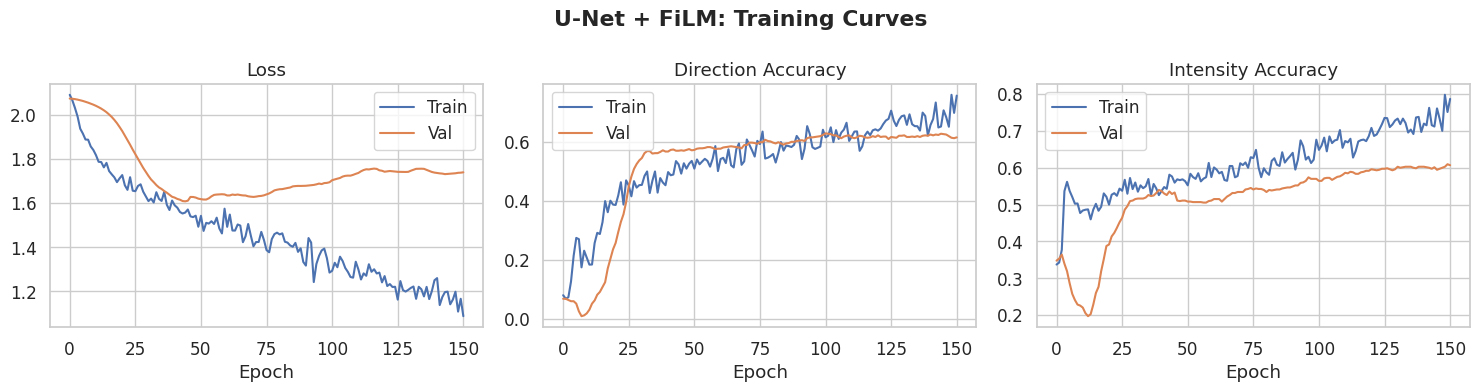

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (t, v, title) in zip(axes, [
    ("train_loss","val_loss","Loss"),
    ("train_dir_acc","val_dir_acc","Direction Accuracy"),
    ("train_int_acc","val_int_acc","Intensity Accuracy")]):
    ax.plot(history[t], label="Train"); ax.plot(history[v], label="Val")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
fig.suptitle("U-Net + FiLM: Training Curves", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "unet_film_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4: WP Evaluation

WP Val — dir=0.629 F1=0.465 | int=0.564 F1=0.471


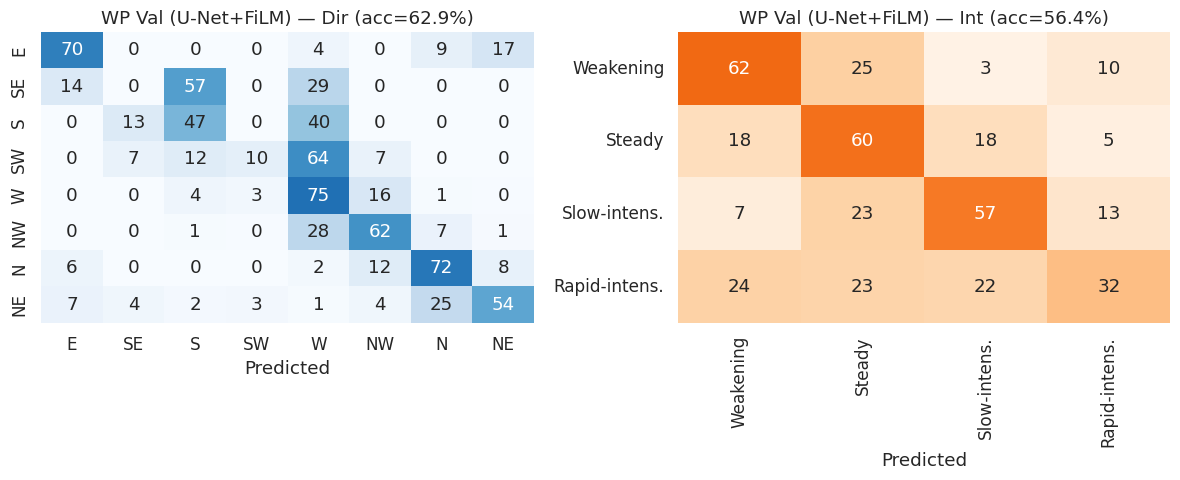

In [11]:
def plot_confusion_matrices(metrics, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, key, labels, cmap in [
        (axes[0], "dir", DIR_LABELS, "Blues"), (axes[1], "int", INTE_LABELS, "Oranges")]:
        cm = confusion_matrix(metrics[f"{key}_true"], metrics[f"{key}_pred"], labels=range(len(labels)))
        cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
        sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap=cmap,
                    xticklabels=labels, yticklabels=labels, cbar=False, ax=ax, vmin=0, vmax=100)
        ax.set_title(f"{title_prefix} — {key.title()} (acc={metrics[f'{key}_acc']:.1%})")
        ax.set_xlabel("Predicted")
    fig.tight_layout()
    return fig

wp_m = evaluate(model, loaders["wp_val"], DEVICE)
print(f"WP Val — dir={wp_m['dir_acc']:.3f} F1={wp_m['dir_f1']:.3f} | int={wp_m['int_acc']:.3f} F1={wp_m['int_f1']:.3f}")
fig = plot_confusion_matrices(wp_m, "WP Val (U-Net+FiLM)")
fig.savefig(FIG_DIR / "unet_film_cm_wp_val.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5: Zero-Shot SP Transfer

SP Zero-Shot — dir=0.390 F1=0.261 | int=0.362
Transfer gap (dir): -0.239


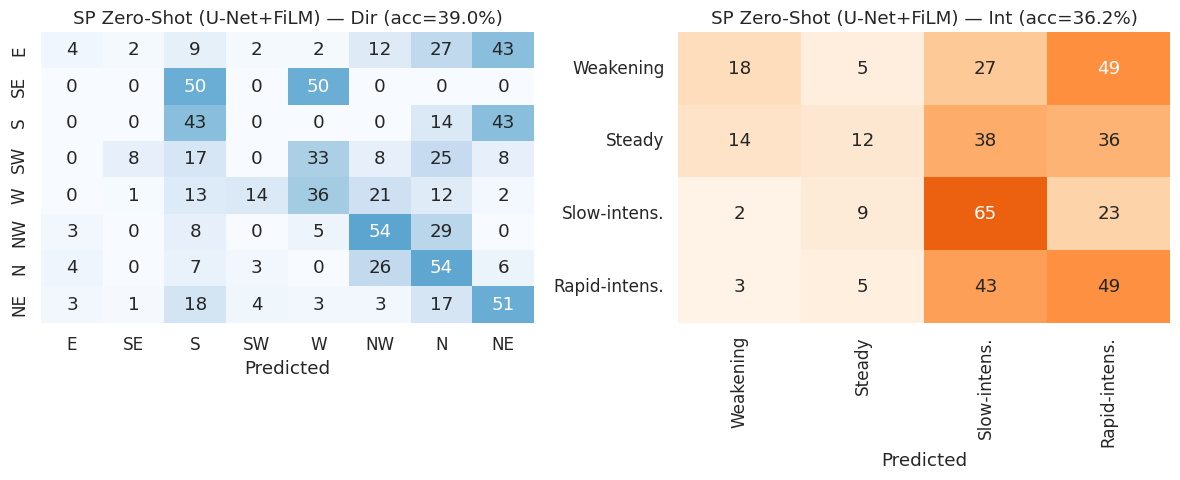

In [12]:
sp_zs = evaluate(model, loaders["sp_test"], DEVICE)
print(f"SP Zero-Shot — dir={sp_zs['dir_acc']:.3f} F1={sp_zs['dir_f1']:.3f} | int={sp_zs['int_acc']:.3f}")
print(f"Transfer gap (dir): {sp_zs['dir_acc'] - wp_m['dir_acc']:+.3f}")
fig = plot_confusion_matrices(sp_zs, "SP Zero-Shot (U-Net+FiLM)")
fig.savefig(FIG_DIR / "unet_film_cm_sp_zs.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6: Fine-Tuning on SP

In [13]:
def finetune(model_state, ft_train_loader, ft_val_loader, freeze_backbone=False,
             lr=FT_LR, epochs=FT_EPOCHS, patience=FT_PATIENCE):
    ft = UNetFiLM2dClassifier(
        in_channels=IN_CHANNELS, base_channels=BASE_CHANNELS, n_levels=N_LEVELS,
        time_dim=TIME_DIM, time_emb_dim=TIME_EMB_DIM,
        use_env=USE_ENV, use_1d=USE_1D,
        dropout=DROPOUT, head_dim=HEAD_DIM, drop_path=DROP_PATH).to(DEVICE)
    ft.load_state_dict(model_state)
    if freeze_backbone:
        for n, p in ft.named_parameters():
            if "head" not in n: p.requires_grad = False
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, ft.parameters()), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    best_acc, best_st, pat = 0.0, None, 0
    hist = {"val_dir_acc": [], "val_loss": []}
    for ep in range(1, epochs+1):
        ft.train()
        for grid, env, d1d, tf, dl, il in ft_train_loader:
            grid,env,d1d,tf,dl,il = [x.to(DEVICE) for x in [grid,env,d1d,tf,dl,il]]
            do, io = ft(grid, env, d1d, tf)
            loss = DIR_WEIGHT*loss_dir_fn(do,dl) + (1-DIR_WEIGHT)*loss_int_fn(io,il)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(ft.parameters(), 1.0); opt.step()
        sched.step()
        vm = evaluate(ft, ft_val_loader, DEVICE)
        hist["val_dir_acc"].append(vm["dir_acc"]); hist["val_loss"].append(vm["loss"])
        if vm["dir_acc"] > best_acc:
            best_acc = vm["dir_acc"]; best_st = deepcopy(ft.state_dict()); pat = 0
        else: pat += 1
        if ep % 10 == 0: print(f"  FT {ep:3d}/{epochs} | dir={vm['dir_acc']:.3f} int={vm['int_acc']:.3f}")
        if pat >= patience: print(f"  Early stop at ep {ep}"); break
    ft.load_state_dict(best_st)
    return ft, hist, best_acc

print("Full fine-tuning:")
ft_full, ft_full_h, ft_full_a = finetune(best_model_state, loaders["sp_ft_train"], loaders["sp_ft_val"])
print(f"  Best: {ft_full_a:.3f}")

print("Head-only:")
ft_head, ft_head_h, ft_head_a = finetune(best_model_state, loaders["sp_ft_train"], loaders["sp_ft_val"], freeze_backbone=True)
print(f"  Best: {ft_head_a:.3f}")

Full fine-tuning:


  FT  10/80 | dir=0.395 int=0.654


  Early stop at ep 17
  Best: 0.457
Head-only:


  FT  10/80 | dir=0.321 int=0.617


  Early stop at ep 16
  Best: 0.333


SP Fine-Tuned — dir=0.390 F1=0.273 | int=0.392


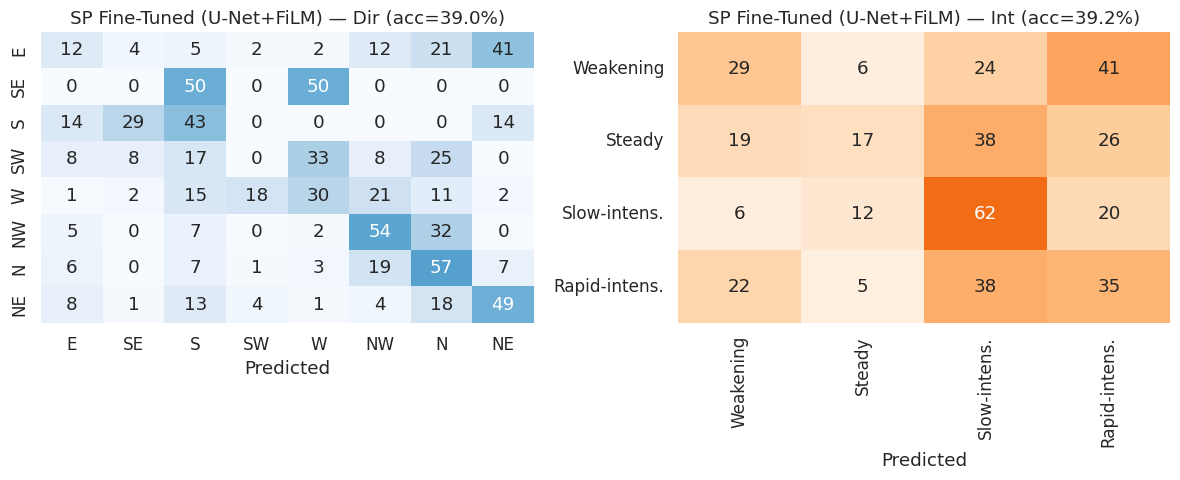

In [14]:
ft_best = ft_full if ft_full_a >= ft_head_a else ft_head
torch.save(ft_best.state_dict(), PROJECT_ROOT / "experiments" / "unet_film_best_ft.pt")

sp_ft = evaluate(ft_best, loaders["sp_test"], DEVICE)
print(f"SP Fine-Tuned — dir={sp_ft['dir_acc']:.3f} F1={sp_ft['dir_f1']:.3f} | int={sp_ft['int_acc']:.3f}")
fig = plot_confusion_matrices(sp_ft, "SP Fine-Tuned (U-Net+FiLM)")
fig.savefig(FIG_DIR / "unet_film_cm_sp_ft.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 7: Summary

In [15]:
print("\n" + "="*80)
print(" U-Net + FiLM — Final Results")
print("="*80)
print(f"{'Setting':20s} | {'Dir Acc':>8s} | {'Dir F1':>7s} | {'Int Acc':>8s} | {'Int F1':>7s}")
print("-"*80)
for name, m in [("WP Val", wp_m), ("SP Zero-Shot", sp_zs), ("SP Fine-Tuned", sp_ft)]:
    print(f"{name:20s} | {m['dir_acc']:>7.1%} | {m['dir_f1']:>6.1%} | {m['int_acc']:>7.1%} | {m['int_f1']:>6.1%}")
print("="*80)
print(f"Parameters: {n_params:,}")
print(f"Transfer gap (dir): {sp_zs['dir_acc'] - wp_m['dir_acc']:+.3f}")
print(f"FT recovery (dir):  {sp_ft['dir_acc'] - sp_zs['dir_acc']:+.3f}")


 U-Net + FiLM — Final Results
Setting              |  Dir Acc |  Dir F1 |  Int Acc |  Int F1
--------------------------------------------------------------------------------
WP Val               |   62.9% |  46.5% |   56.4% |  47.1%
SP Zero-Shot         |   39.0% |  26.1% |   36.2% |  30.1%
SP Fine-Tuned        |   39.0% |  27.3% |   39.2% |  33.1%
Parameters: 10,029,156
Transfer gap (dir): -0.239
FT recovery (dir):  +0.000
